# 


Tugas 1 - Klasifikasi Wine Quality dengan KNN
  
| Nama              | NRP        |
|-------------------|------------|
| Aziz Rahmad Arifin| 5054251002 |

## Deskripsi Tugas
Pada tugas ini, kita akan menggunakan Wine Quality Dataset. Dataset bisa diakses melalui link berikut:\
🔗 https://www.kaggle.com/datasets/yasserh/wine-quality-dataset

Tujuan utama dari tugas ini adalah membangun model K-Nearest Neighbors (KNN) untuk mengklasifikasikan kualitas wine.

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset & Eksplorasi Awal

- Memuat dataset, melihat struktur data, dan distribusi label.

2. Preprocessing
- Memproses data agar siap untuk digunakan dalam membangun model.

3. Eksperimen Model KNN
- Bangun model KNN dengan mencoba beberapa nilai k (misalnya 3, 5, dan 7 --> BEBAS) serta dua metric jarak (seperti Euclidean dan Manhattan).
- Eksperimen ini bertujuan untuk membandingkan performa KNN dengan parameter yang berbeda.

4. Evaluasi Model
- Hitung metrik evaluasi seperti Accuracy, Precision, Recall, F1-Score, serta visualisasikan Confusion Matrix.

5. Analisis & Kesimpulan
- Bandingkan hasil antar eksperimen yang telah dilakukan dan berikan kesimpulan.


# 1. Persiapan Dataset & Eksplorasi Awal

In [1]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, dll)
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

In [5]:
#  Load Dataset dan menampilkan informasi dasar tentang dataset, seperti jumlah baris dan kolom, tipe data, jumlah nilai yang hilang, dan informasi lainnya yang dibutuhkan.

'''

data = pd.read_csv('namafile.csv')
data.head()
data.info()
data.describe()

! Cari fungsi-fungsi yang dapat digunakan untuk menampilkan informasi yang diinginkan.

'''

data = pd.read_csv('/kaggle/input/datasets/yasserh/wine-quality-dataset/WineQT.csv')
data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


### Terdapat kolom **ID** yang kurang berguna (Bukan fitur), jadi bisa dihilangkan


In [6]:
# Menghapus kolom Id
data = data.drop(columns=['Id'])
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 107.3 KB


#### Tidak ada nilai kosong (NaN)

In [7]:
data.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

#### Tidak Ada Missing Values

In [8]:
data.duplicated().sum()

np.int64(125)

#### Tidak ada duplikat

In [9]:
# Cek statistik dan kemungkinan outlier
data.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


#### - Dataset terdiri dari 1143 data dan seluruh kolom memiliki jumlah data yang lengkap
#### - Kualitas rerata wine adalah 5,65 dari rentang 3-8. Jadi kualitas wine secara umumm bisa dikatakan dalam tingkat sedang
#### - Kadar Alkohol dalam wine memiliki rerata sebesar 10,44 persen dari rentang 8,4 - 14,9 persen.
#### - Volatile Acidity ( Tingkat Keasaman yang mudah menguap pada wine) memiliki rerata sebesar 0,53
#### - Rerata pH sebesar 3,3 dari rentang 2,74 - 4
#### - Beberapa variabel seperti residual sugar, chlorides, total sulfur dioxide, dan sulphates memiliki rentang nilai yang cukup jauh, sehingga terdapat kemungkinan outlier


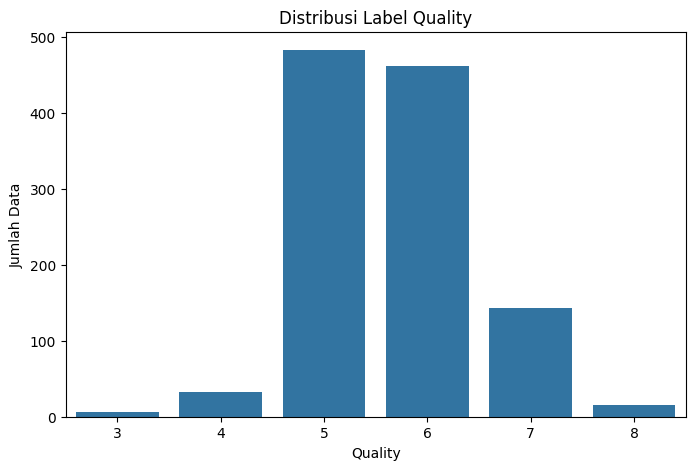

In [10]:
# Tampilkan distribusi label (quality) dalam bentuk visualisasi, misalnya menggunakan histogram atau bar plot.
quality_counts= data['quality'].value_counts().sort_index()

plt.figure(figsize=(8,5))
sns.barplot(
    x= quality_counts.index,
    y= quality_counts.values
)
plt.title("Distribusi Label Quality")
plt.xlabel("Quality")
plt.ylabel("Jumlah Data")
plt.show()

In [11]:
# Cek nilai unik pada target
print(data['quality'].value_counts().sort_index().to_frame('jumlah').assign(
    persentase=lambda x: (x['jumlah'] / len(data) * 100).round(2)
))

         jumlah  persentase
quality                    
3             6        0.52
4            33        2.89
5           483       42.26
6           462       40.42
7           143       12.51
8            16        1.40


#### - Quality 5 merupakan kelas terbanyak dengan 483 data (42,26%), diikuti quality 6 sebanyak 462 data (40,42%). 
#### - Sementara itu, quality 3 dan 8 hanya memiliki masing-masing 0,52% dan 1,40% dari total data.
#### Hal ini menunjukkan adanya ketidakseimbangan kelas (class imbalance), sehingga perlu diperhatikan pada tahap pemodelan dan evaluasi.

In [12]:
# ============================================================
# Menampilkan Nilai Outlier pada Setiap Fitur
# ============================================================

# Fitur yang digunakan untuk analisis dan pemodelan
features = [
    'fixed acidity',
    'volatile acidity',
    'citric acid',
    'residual sugar',
    'chlorides',
    'free sulfur dioxide',
    'total sulfur dioxide',
    'density',
    'pH',
    'sulphates',
    'alcohol'
]

# Menghitung Q1, Q3, dan IQR
Q1 = data[features].quantile(0.25)
Q3 = data[features].quantile(0.75)
IQR = Q3 - Q1

# Menentukan batas bawah dan atas
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR


for feature in features:
    mask = (
        (data[feature] < lower_bound[feature]) |
        (data[feature] > upper_bound[feature])
    )

    outliers = data.loc[mask, feature]

    print(f"\n{'=' * 60}")
    print(f"Fitur: {feature}")
    print(f"Jumlah outlier: {len(outliers)}")
    print(f"{'=' * 60}")
    print(outliers.tolist())



Fitur: fixed acidity
Jumlah outlier: 44
[12.8, 12.8, 15.0, 15.0, 12.5, 13.3, 13.4, 12.5, 13.8, 13.5, 12.6, 12.5, 12.8, 12.8, 13.7, 12.2, 12.5, 12.8, 12.3, 12.3, 12.6, 15.6, 12.5, 13.0, 12.5, 13.3, 12.5, 12.9, 14.3, 12.4, 15.5, 15.6, 13.0, 12.7, 13.0, 12.7, 12.3, 12.3, 12.4, 13.2, 15.9, 12.9, 12.6, 12.6]

Fitur: volatile acidity
Jumlah outlier: 14
[1.02, 1.07, 1.33, 1.33, 1.04, 1.09, 1.04, 1.02, 1.035, 1.025, 1.02, 1.58, 1.18, 1.04]

Fitur: citric acid
Jumlah outlier: 1
[1.0]

Fitur: residual sugar
Jumlah outlier: 110
[5.5, 5.9, 4.65, 4.65, 5.5, 5.5, 5.5, 7.3, 7.2, 5.6, 4.0, 4.0, 4.0, 4.0, 6.4, 5.6, 5.6, 11.0, 11.0, 4.5, 4.8, 5.8, 5.8, 6.2, 4.2, 7.9, 7.9, 4.5, 6.7, 6.6, 3.7, 5.2, 15.5, 8.3, 6.55, 6.55, 6.1, 4.3, 5.8, 5.15, 6.3, 4.2, 4.6, 4.2, 4.3, 4.3, 7.9, 5.1, 5.6, 8.6, 7.5, 6.0, 3.9, 4.2, 4.0, 6.6, 6.0, 3.8, 9.0, 8.8, 5.0, 3.8, 4.1, 5.9, 4.1, 6.2, 4.0, 3.9, 4.0, 8.1, 6.4, 8.3, 8.3, 4.7, 5.5, 5.5, 4.3, 5.5, 3.7, 6.2, 5.6, 4.6, 5.8, 4.1, 4.3, 4.8, 6.3, 4.5, 4.5, 4.3, 3.8, 5.4, 6.1, 5.

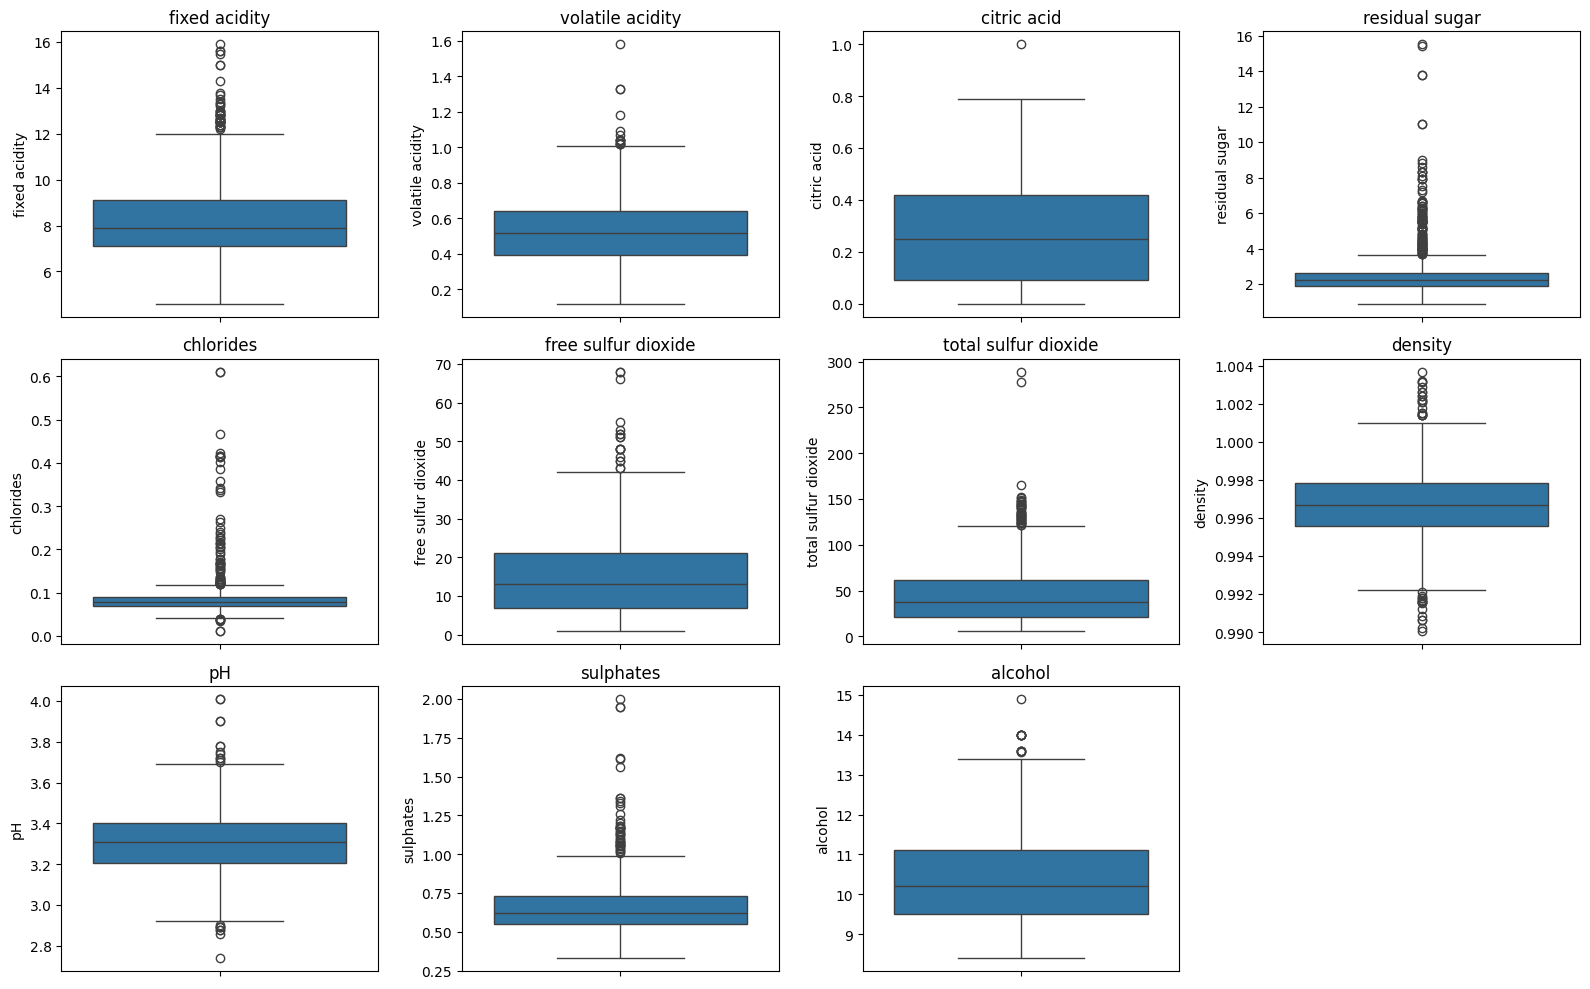

In [13]:
# Boxplot masing-masing fitur
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.boxplot(y=data[feature], ax=axes[i])
    axes[i].set_title(feature)

# Hapus subplot yang tidak terpakai
for i in range(len(features), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

In [14]:
# Periksa Outliers (jika diperlukan), misalnya menggunakan boxplot atau metode statistik lainnya. (Bisa dilakukan eksperimen dengan dan tanpa outlier untuk melihat perbedaan performa model)

# ============================================================
# Analisis Outlier dengan Metode IQR
# ============================================================

# Menentukan batas bawah dan batas atas
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Menghitung jumlah outlier
outlier_count = (
    (data[features] < lower_bound) |
    (data[features] > upper_bound)
).sum()

# Menghitung persentase outlier
outlier_percentage = (outlier_count / len(data)) * 100

# Membuat tabel hasil
outlier_table = pd.DataFrame({
    'Fitur': features,
    'Q1': Q1.values,
    'Q3': Q3.values,
    'IQR': IQR.values,
    'Lower Bound': lower_bound.values,
    'Upper Bound': upper_bound.values,
    'Jumlah Outlier': outlier_count.values,
    'Persentase (%)': outlier_percentage.values
})

# Menampilkan hasil
outlier_table.round(2)


,Fitur,Q1,Q3,IQR,Lower Bound,Upper Bound,Jumlah Outlier,Persentase (%)
0,fixed acidity,7.10,9.10,2.00,4.10,12.10,44,3.85
1,volatile acidity,0.39,0.64,0.25,0.02,1.01,14,1.22
2,citric acid,0.09,0.42,0.33,-0.40,0.91,1,0.09
3,residual sugar,1.90,2.60,0.70,0.85,3.65,110,9.62
4,chlorides,0.07,0.09,0.02,0.04,0.12,77,6.74
5,free sulfur dioxide,7.00,21.00,14.00,-14.00,42.00,18,1.57
6,total sulfur dioxide,21.00,61.00,40.00,-39.00,121.00,40,3.50
7,density,1.00,1.00,0.00,0.99,1.00,36,3.15
8,pH,3.20,3.40,0.19,2.91,3.69,20,1.75
9,sulphates,0.55,0.73,0.18,0.28,1.00,43,3.76


### Analisis Outlier

Berdasarkan metode **Interquartile Range (IQR)**, `residual sugar` memiliki jumlah outlier terbesar, yaitu **110 data (9,62%)**, diikuti oleh `chlorides` sebanyak **77 data (6,74%)**.

Fitur dengan jumlah outlier terbanyak:

- **Residual sugar:** 110 data (9,62%)
- **Chlorides:** 77 data (6,74%)
- **Fixed acidity:** 44 data (3,85%)
- **Sulphates:** 43 data (3,76%)
- **Total sulfur dioxide:** 40 data (3,50%)

Sebaliknya, `citric acid` memiliki jumlah outlier paling sedikit, yaitu hanya **1 data (0,09%)**.

#### Analisis Outlier pada `Chlorides`

Fitur `chlorides` cukup menarik karena memiliki outlier pada **dua sisi distribusi**, yaitu nilai yang sangat tinggi maupun sangat rendah.

Beberapa nilai outlier yang ditemukan antara lain:

- **Nilai tinggi:** `0.341`, `0.467`, `0.610`, `0.611`
- **Nilai rendah:** `0.012`, `0.034`, `0.038`

Hal ini menunjukkan bahwa terdapat beberapa observasi `chlorides` yang berada cukup jauh dari nilai pusat distribusi data.

> **Catatan:** Outlier tidak langsung dianggap sebagai kesalahan data. Nilai ekstrem dapat merupakan observasi yang valid. Oleh karena itu, penanganan outlier akan dipertimbangkan pada tahap **preprocessing** dan dapat diuji dengan membandingkan performa model **dengan dan tanpa penanganan outlier**.


In [12]:
# Tampilkan Korelasi Matrix
corr_matrix= data.corr(numeric_only= True)
print(corr_matrix)

                      fixed acidity  volatile acidity  citric acid  \
fixed acidity              1.000000         -0.250728     0.673157   
volatile acidity          -0.250728          1.000000    -0.544187   
citric acid                0.673157         -0.544187     1.000000   
residual sugar             0.171831         -0.005751     0.175815   
chlorides                  0.107889          0.056336     0.245312   
free sulfur dioxide       -0.164831         -0.001962    -0.057589   
total sulfur dioxide      -0.110628          0.077748     0.036871   
density                    0.681501          0.016512     0.375243   
pH                        -0.685163          0.221492    -0.546339   
sulphates                  0.174592         -0.276079     0.331232   
alcohol                   -0.075055         -0.203909     0.106250   
quality                    0.121970         -0.407394     0.240821   

                      residual sugar  chlorides  free sulfur dioxide  \
fixed acidity    

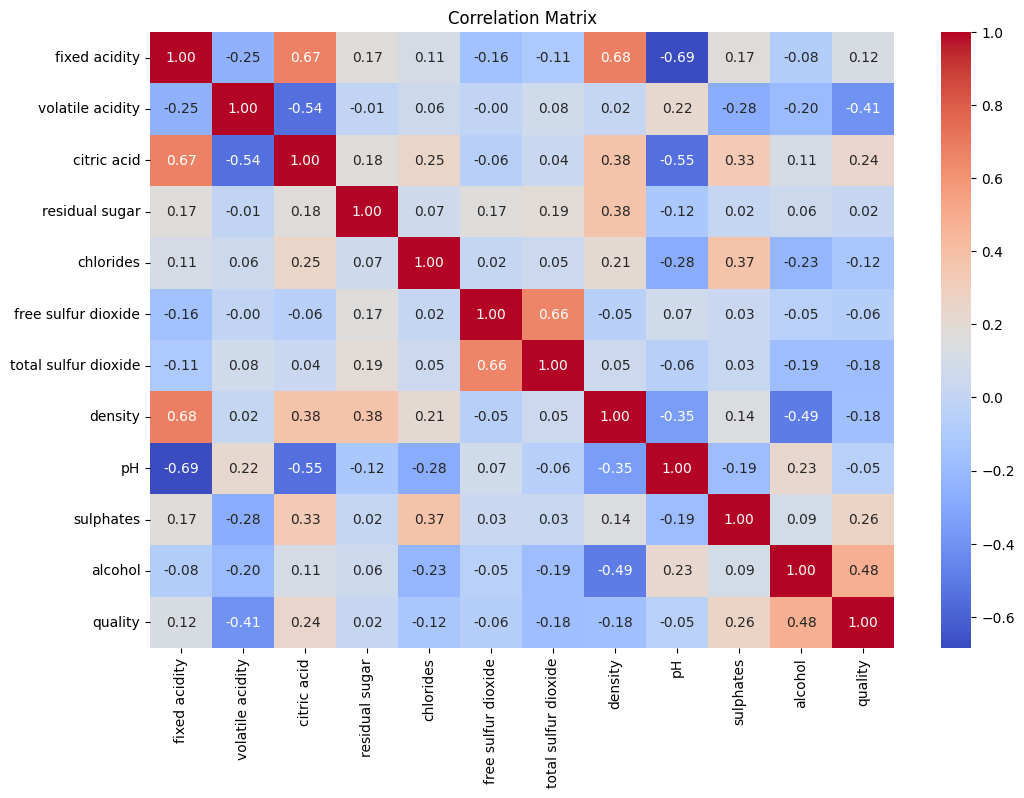

In [13]:
# Menampilkan Correlation Matrix
corr_matrix = data.corr(numeric_only=True)

plt.figure(figsize=(12, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix')
plt.show()


In [16]:
# Korelasi fitur terhadap quality
quality_corr = data.corr(numeric_only=True)['quality'].drop('quality')

print(quality_corr)


fixed acidity           0.121970
volatile acidity       -0.407394
citric acid             0.240821
residual sugar          0.022002
chlorides              -0.124085
free sulfur dioxide    -0.063260
total sulfur dioxide   -0.183339
density                -0.175208
pH                     -0.052453
sulphates               0.257710
alcohol                 0.484866
Name: quality, dtype: float64


## Kesimpulan Korelasi

Berdasarkan matriks korelasi tersebut, dapat disimpulkan:

- **Alcohol** memiliki korelasi positif paling kuat dengan **quality**, yaitu sebesar **0,485**. Artinya, semakin tinggi kadar alkohol, cenderung semakin tinggi kualitas wine.
- **Volatile acidity** memiliki korelasi negatif paling kuat dengan **quality**, yaitu sebesar **-0,407**. Artinya, peningkatan volatile acidity cenderung berkaitan dengan penurunan kualitas wine.
- **Sulphates** memiliki korelasi positif dengan **quality** sebesar **0,258**, sedangkan **citric acid** sebesar **0,241**. Hubungannya positif tetapi relatif lemah.
- **Density** memiliki korelasi negatif dengan **alcohol** sebesar **-0,495**. Artinya, wine dengan kadar alkohol lebih tinggi cenderung memiliki density yang lebih rendah.
- Terdapat korelasi yang cukup kuat antar beberapa fitur:
  - **Fixed acidity – pH:** -0,685
  - **Fixed acidity – density:** 0,682
  - **Free sulfur dioxide – total sulfur dioxide:** 0,661
- **Residual sugar** memiliki korelasi yang sangat lemah dengan **quality**, yaitu sebesar **0,022**, sehingga variabel ini hampir tidak memiliki hubungan linear dengan kualitas wine.
- **Id** memiliki korelasi yang sangat lemah dengan **quality**, yaitu sebesar **0,070**, sehingga variabel ini kemungkinan tidak memberikan informasi yang berarti dalam memprediksi kualitas wine.


Secara keseluruhan, distribusi label `quality` **tidak seimbang (imbalanced)**. Data lebih banyak terkonsentrasi pada quality **5 dan 6**, sedangkan quality **3, 4, 7, dan 8** memiliki jumlah data yang jauh lebih sedikit.

In [17]:
import pandas as pd

# 1. Pisahkan fitur (X) dan target (y)
# (Sesuaikan nama variabel df dengan nama dataframe Anda, misal: df_wine)
X = data.drop(columns=['quality']) 

# 2. Hitung nilai skewness untuk semua fitur numerik
skewness = X.skew()

# 3. Buat dataframe untuk merangkum hasil dan memberikan rekomendasi
df_rekomendasi = pd.DataFrame({
    'Nilai Skewness': skewness,
})

# 4. Berikan logika rekomendasi scaler berdasarkan nilai skewness
def tentukan_scaler(skew_val):
    # Jika skewness mendekati 0 (-0.5 sampai 0.5), data berbentuk lonceng
    if -0.5 <= skew_val <= 0.5:
        return "StandardScaler (Bentuk Lonceng / Normal)"
    # Jika skewness ekstrem (di atas 1 atau di bawah -1), biasanya banyak outliers
    elif skew_val > 1.0 or skew_val < -1.0:
        return "RobustScaler (Miring Ekstrem & Banyak Outliers)"
    # Rentang moderat (-1 s/d -0.5 atau 0.5 s/d 1)
    else:
        return "MinMaxScaler / StandardScaler (Miring Ringan)"

df_rekomendasi['Rekomendasi Scaler'] = df_rekomendasi['Nilai Skewness'].apply(tentukan_scaler)

# Tampilkan hasil analisis
print("=== ANALISIS DISTRIBUSI & REKOMENDASI SCALER ===")
print(df_rekomendasi)



=== ANALISIS DISTRIBUSI & REKOMENDASI SCALER ===
                      Nilai Skewness  \
fixed acidity               1.044930   
volatile acidity            0.681547   
citric acid                 0.371561   
residual sugar              4.361096   
chlorides                   6.026360   
free sulfur dioxide         1.231261   
total sulfur dioxide        1.665766   
density                     0.102395   
pH                          0.221138   
sulphates                   2.497266   
alcohol                     0.863313   

                                                   Rekomendasi Scaler  
fixed acidity         RobustScaler (Miring Ekstrem & Banyak Outliers)  
volatile acidity        MinMaxScaler / StandardScaler (Miring Ringan)  
citric acid                  StandardScaler (Bentuk Lonceng / Normal)  
residual sugar        RobustScaler (Miring Ekstrem & Banyak Outliers)  
chlorides             RobustScaler (Miring Ekstrem & Banyak Outliers)  
free sulfur dioxide   RobustScaler (Mi

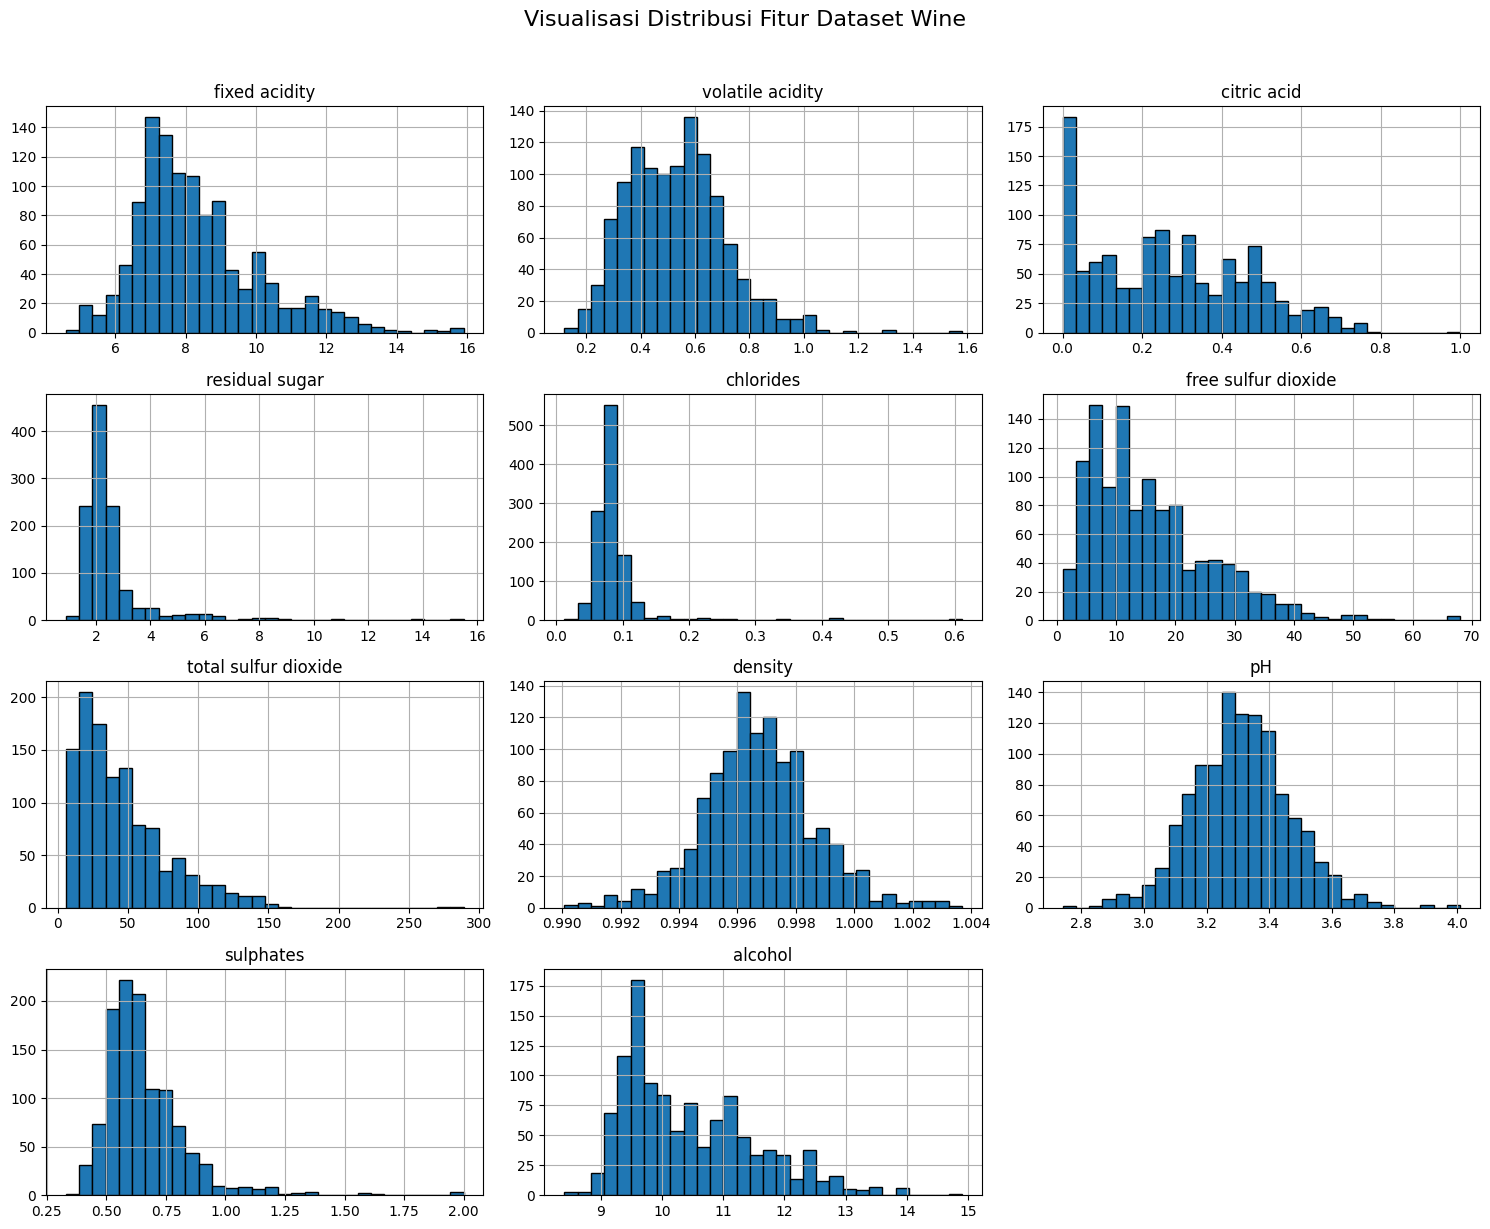

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Membuat grid visualisasi untuk semua fitur
X.hist(figsize=(15, 12), bins=30, edgecolor='black')
plt.suptitle("Visualisasi Distribusi Fitur Dataset Wine", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


## Analisis Distribusi Data

Berdasarkan hasil analisis **skewness**, dapat diketahui bahwa setiap fitur memiliki tingkat kemencengan distribusi yang berbeda. Nilai skewness yang mendekati 0 menunjukkan distribusi yang relatif simetris, sedangkan semakin besar nilai skewness menunjukkan distribusi yang semakin menceng ke kanan.

### Interpretasi Hasil

- **Citric acid (0.372), density (0.102), dan pH (0.221)** memiliki nilai skewness kurang dari 0.5. Hal ini menunjukkan bahwa ketiga fitur tersebut memiliki distribusi yang relatif simetris.

- **Volatile acidity (0.682) dan alcohol (0.863)** memiliki skewness sedang. Distribusinya mengalami sedikit kemencengan ke kanan, tetapi masih relatif terkendali.

- **Fixed acidity (1.045), free sulfur dioxide (1.231), dan total sulfur dioxide (1.666)** memiliki skewness lebih dari 1. Hal ini menunjukkan adanya kemencengan distribusi yang cukup kuat dan kemungkinan terdapat nilai ekstrem.

- **Residual sugar (4.361), chlorides (6.026), dan sulphates (2.497)** memiliki nilai skewness yang sangat tinggi. Ketiga fitur tersebut menunjukkan distribusi yang sangat menceng ke kanan dan perlu mendapat perhatian khusus karena kemungkinan memiliki pengaruh outlier yang cukup besar.

In [18]:
# Scaling data (jika diperlukan), misalnya menggunakan StandardScaler atau MinMaxScaler. (Bisa dilakukan eksperimen dengan dan tanpa scaling untuk melihat perbedaan performa model)
# Perhatikan data leakage saat melakukan scaling. Scaling harus dilakukan setelah membagi data menjadi train dan test set.

#### Menggunakan algoritma KNN (K-Nearest Neighbors) pada dataset multiclass yang imbalance (6 kategori, 2 kelas mendominasi 81%) memiliki tantangan tersendiri. Secara alami, KNN sangat sensitif terhadap data imbalance karena prediksi diambil berdasarkan mayoritas tetangga terdekat. Jika data mayoritas terlalu dominan, tetangga terdekat hampir selalu berasal dari 2 kelas dominan tersebut.

# 2. Preprocessing


In [19]:
# Memisahkan fitur dan target
X= data.drop(columns=['quality'])
Y= data['quality']

print(f'Shape X: {X.shape}')
print(f'Shape : {Y.shape}')

Shape X: (1143, 11)
Shape : (1143,)


## TRAIN TEST SPLIT
#### Karena target imbalance, stratify=y supaya distribusi quality pada data train dan test tetep kurang lebih sama

In [19]:
from sklearn.model_selection import train_test_split

X = data.drop(columns=['quality'])
Y = data['quality']

X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42,
    stratify=Y
)


print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", Y_train.shape)
print("y_test :", Y_test.shape)

X_train: (914, 11)
X_test : (229, 11)
y_train: (914,)
y_test : (229,)


In [20]:
print("Total:")
print(Y.value_counts().sort_index())

print("\nTrain:")
print(Y_train.value_counts().sort_index())

print("\nTest:")
print(Y_test.value_counts().sort_index())


Total:
quality
3      6
4     33
5    483
6    462
7    143
8     16
Name: count, dtype: int64

Train:
quality
3      5
4     26
5    386
6    370
7    114
8     13
Name: count, dtype: int64

Test:
quality
3     1
4     7
5    97
6    92
7    29
8     3
Name: count, dtype: int64


In [22]:
# print("Distribusi data asli:")
# print(Y.value_counts().sort_index())

# print("\nDistribusi data training:")
# print(Y_train.value_counts().sort_index())

# print("\nDistribusi data testing:")
# print(Y_test.value_counts().sort_index())


## Skenario Penggunaan Scaler

### 1. StandardScaler

**StandardScaler** merupakan metode scaling yang melakukan standarisasi data berdasarkan **mean (rata-rata)** dan **standard deviation (standar deviasi)**.

Rumus StandardScaler adalah:

$$
z = \frac{x - \mu}{\sigma}
$$

Keterangan:

- $x$ = nilai asli data
- $\mu$ = mean atau rata-rata data
- $\sigma$ = standard deviation atau standar deviasi
- $z$ = nilai setelah scaling

Setelah dilakukan scaling, data akan memiliki rata-rata mendekati $0$ dan standar deviasi mendekati $1$.

**Kelebihan:**
- Cocok untuk data yang memiliki distribusi relatif normal.
- Umum digunakan pada algoritma yang sensitif terhadap skala data, termasuk **K-Nearest Neighbors (KNN)**.

**Kekurangan:**
- Sensitif terhadap **outlier** karena mean dan standar deviasi dapat dipengaruhi oleh nilai ekstrem.

---

### 2. RobustScaler

**RobustScaler** merupakan metode scaling yang menggunakan **median** dan **Interquartile Range (IQR)** sehingga lebih tahan terhadap pengaruh outlier.

Rumus RobustScaler adalah:

$$
x' = \frac{x - Q_2}{Q_3 - Q_1}
$$

Keterangan:

- $x$ = nilai asli data
- $Q_1$ = kuartil pertama (25%)
- $Q_2$ = median (50%)
- $Q_3$ = kuartil ketiga (75%)
- $Q_3 - Q_1$ = Interquartile Range (IQR)
- $x'$ = nilai setelah scaling

Berbeda dengan StandardScaler yang menggunakan mean dan standar deviasi, RobustScaler menggunakan **median dan IQR** yang relatif tidak terpengaruh oleh nilai ekstrem.

**Kelebihan:**
- Lebih tahan terhadap outlier.
- Cocok untuk data dengan distribusi menceng (*skewed*).
- Mengurangi pengaruh nilai ekstrem terhadap skala data.

**Kekurangan:**
- Tidak membuat distribusi data menjadi normal.
- Pada data yang tidak memiliki outlier, StandardScaler dapat memberikan hasil yang lebih sesuai pada beberapa kondisi.

---

## Pengaruh Scaling pada KNN

Algoritma **K-Nearest Neighbors (KNN)** menentukan tetangga terdekat berdasarkan ukuran **jarak atau ketidakmiripan (distance/dissimilarity)** antar data. Oleh karena itu, skala setiap fitur dapat memengaruhi hasil pencarian tetangga terdekat.

Beberapa ukuran jarak yang dapat digunakan pada KNN antara lain:

### Euclidean Distance

$$
d(x,y) = \sqrt{\sum_{i=1}^{n}(x_i-y_i)^2}
$$

Euclidean Distance mengukur jarak garis lurus antara dua titik. Metode ini sensitif terhadap perbedaan skala dan nilai ekstrem.

### Manhattan Distance

$$
d(x,y) = \sum_{i=1}^{n}|x_i-y_i|
$$

Manhattan Distance menghitung total perbedaan absolut pada setiap fitur. Meskipun tidak menggunakan kuadrat seperti Euclidean Distance, perbedaan skala antar fitur tetap dapat memengaruhi hasil jarak.

### Minkowski Distance

$$
d(x,y) =
\left(
\sum_{i=1}^{n}|x_i-y_i|^p
\right)^{\frac{1}{p}}
$$

Minkowski Distance merupakan bentuk umum dari beberapa metode jarak. Nilai $p$ menentukan jenis jarak yang digunakan. Misalnya, $p=2$ menghasilkan Euclidean Distance, sedangkan $p=1$ menghasilkan Manhattan Distance.

Dengan demikian, **scaling tetap penting pada KNN**, terlepas dari jenis distance yang digunakan, karena fitur dengan rentang nilai yang lebih besar dapat memberikan pengaruh yang lebih besar dalam menentukan kedekatan antar-observasi.

---

## Alasan Memilih RobustScaler

Berdasarkan hasil analisis distribusi, terdapat beberapa fitur dengan nilai **skewness yang tinggi**, seperti `residual sugar` sebesar $4.36$, `chlorides` sebesar $6.03$, dan `sulphates` sebesar $2.50$. Nilai tersebut menunjukkan bahwa beberapa fitur memiliki distribusi yang sangat menceng dan berpotensi memiliki nilai ekstrem (*outlier*).

Kondisi tersebut menjadi pertimbangan dalam pemilihan scaler. **StandardScaler menggunakan mean dan standard deviation**, sehingga hasil scaling dapat lebih mudah dipengaruhi oleh nilai ekstrem. Sebaliknya, **RobustScaler menggunakan median dan IQR**, yang relatif lebih stabil terhadap outlier.

Karena KNN menggunakan perhitungan jarak untuk menentukan tetangga terdekat, pengaruh nilai ekstrem dan perbedaan skala dapat memengaruhi hasil klasifikasi. Oleh karena itu, **RobustScaler dipilih sebagai metode scaling yang lebih sesuai untuk dataset ini**, terutama karena terdapat beberapa fitur dengan skewness yang tinggi dan indikasi nilai ekstrem.

Selanjutnya, performa RobustScaler dapat dibandingkan dengan StandardScaler menggunakan **cross-validation** untuk memastikan metode scaling yang memberikan performa terbaik pada model KNN.
```

### 1. Standar Scaler

In [32]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

scaler = StandardScaler()

X_train_standarscaled = scaler.fit_transform(X_train)
X_test_standarscaled = scaler.transform(X_test)

# Mengubah hasil scaling menjadi DataFrame
X_train_standarscaled_df = pd.DataFrame(
    X_train_standarscaled,
    columns=X_train.columns,
    index=X_train.index
)

print("=== X_train Sebelum StandardScaler ===")
display(X_train.head(1))

print("=== X_train Sesudah StandardScaler ===")
display(X_train_standarscaled_df.head(1))


=== X_train Sebelum StandardScaler ===


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
819,8.3,0.6,0.25,2.2,0.118,9.0,38.0,0.99616,3.15,0.53,9.8


=== X_train Sesudah StandardScaler ===


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
819,-0.012101,0.388684,-0.109113,-0.264324,0.609897,-0.643427,-0.236286,-0.299229,-1.039511,-0.731171,-0.608473


### 2. Robust Scaler

In [33]:
from sklearn.preprocessing import RobustScaler
import pandas as pd

scaler = RobustScaler()

X_train_Robustscaled = scaler.fit_transform(X_train)
X_test_Robustscaled = scaler.transform(X_test)

# Mengubah hasil scaling menjadi DataFrame
X_train_Robustscaled_df = pd.DataFrame(
    X_train_Robustscaled,
    columns=X_train.columns,
    index=X_train.index
)

print("=== X_train Sebelum RobustScaler ===")
display(X_train.head(1))

print("=== X_train Sesudah RobustScaler ===")
display(X_train_Robustscaled_df.head(1))


=== X_train Sebelum RobustScaler ===


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
819,8.3,0.6,0.25,2.2,0.118,9.0,38.0,0.99616,3.15,0.53,9.8


=== X_train Sesudah RobustScaler ===


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
819,0.2,0.32,-0.015625,0.0,1.95,-0.285714,0.025,-0.24,-0.842105,-0.529412,-0.25


#### saya memakai scaling karena fitur total sulfur dioxida yang memiliki range besar. 
- pH                  2.74 – 4.01
- density             0.990 – 1.004
- total sulfur dioxide 6 – 289
- alcohol             8.4 – 14.9

#### Kalau langsung menggunakan KNN tanpa scaling, fitur seperti total sulfur dioxide berpotensi memberikan kontribusi yang jauh lebih besar terhadap jarak dibandingkan pH atau density.

#### Setelah diScaler, setiap fitur berada pada skala yang sebanding.


# 3. Eksperimen Model KNN


In [26]:
# Split data menjadi train dan test set. (misal 80% train, 20% test)
# Gunakan fungsi train_test_split dari sklearn.model_selection untuk membagi data menjadi train dan test set. Pastikan untuk memisahkan fitur (X) dan label (y) sebelum melakukan split.
# Gunakan stratify=y agar distribusi label pada train dan test set tetap sama dengan distribusi label pada dataset asli.
# Train model KNN menggunakan train set. Gunakan fungsi KNeighborsClassifier dari sklearn.neighbors untuk membuat model KNN. Lakukan eksperimen dengan berbagai nilai k (misal k=1, 3, 5, 7, 9) dan catat performa model pada train set dan test set.

## Skenario Eksperimen K-Nearest Neighbors (KNN)

Pada penelitian ini dilakukan eksperimen untuk mengetahui pengaruh **metode
scaling**, **distance metric**, **weight**, dan nilai **K** terhadap performa
algoritma **K-Nearest Neighbors (KNN)** dalam melakukan klasifikasi kualitas
wine.

Berdasarkan hasil EDA, dataset memiliki perbedaan skala antarfitur yang cukup
besar serta beberapa fitur memiliki skewness dan outlier yang cukup tinggi.
Oleh karena itu, digunakan beberapa metode scaling untuk mengetahui metode
yang paling sesuai dengan karakteristik dataset.

Eksperimen dilakukan **tanpa Feature Selection**, sehingga seluruh fitur
prediktor digunakan dalam proses klasifikasi.

---

### 1. Feature Selection

Pada eksperimen ini **tidak dilakukan Feature Selection**. Seluruh 11 fitur
numerik digunakan sebagai variabel prediktor, yaitu:

- `fixed acidity`
- `volatile acidity`
- `citric acid`
- `residual sugar`
- `chlorides`
- `free sulfur dioxide`
- `total sulfur dioxide`
- `density`
- `pH`
- `sulphates`
- `alcohol`

Variabel `quality` digunakan sebagai target klasifikasi, sedangkan `Id` tidak
digunakan sebagai fitur karena hanya berfungsi sebagai identitas data dan
tidak memiliki makna prediktif terhadap kualitas wine.

Dengan demikian:

$$
\boxed{\text{Feature Selection = Tidak digunakan}}
$$

---

### 2. Skenario Scaling

Terdapat tiga kondisi scaling yang dibandingkan:

| Kode | Scaling | Keterangan |
|:---:|---|---|
| S1 | Tanpa Scaling | Data digunakan dalam skala aslinya |
| S2 | StandardScaler | Standardisasi berdasarkan mean dan standard deviation |
| S3 | RobustScaler | Scaling berdasarkan median dan IQR |

#### StandardScaler

StandardScaler melakukan standardisasi dengan rumus:

$$
z = \frac{x-\mu}{\sigma}
$$

dengan:

- $x$ = nilai asli fitur
- $\mu$ = mean
- $\sigma$ = standard deviation

Metode ini membuat fitur memiliki skala yang relatif seragam dengan pusat
distribusi di sekitar 0.

#### RobustScaler

RobustScaler menggunakan median dan Interquartile Range (IQR):

$$
x' = \frac{x-\text{Median}(X)}{IQR(X)}
$$

dengan:

$$
IQR = Q_3-Q_1
$$

Metode ini lebih tahan terhadap pengaruh outlier dibandingkan StandardScaler.

Berdasarkan hasil EDA, beberapa fitur seperti `residual sugar` dan `chlorides`
memiliki skewness yang tinggi serta jumlah outlier yang cukup banyak. Oleh
karena itu, RobustScaler layak diuji dan dibandingkan dengan StandardScaler.

---

### 3. Skenario Distance Metric

KNN menggunakan jarak untuk menentukan kedekatan antar data. Pada eksperimen
ini digunakan tiga distance metric:

| Kode | Distance | Parameter |
|:---:|---|---|
| D1 | Euclidean | $p=2$ |
| D2 | Manhattan | $p=1$ |
| D3 | Minkowski | $p=3$ |

#### Euclidean Distance

Euclidean mengukur jarak lurus antara dua titik:

$$
d(x,y)=
\sqrt{
\sum_{i=1}^{n}(x_i-y_i)^2
}
$$

#### Manhattan Distance

Manhattan menghitung jumlah selisih absolut antar fitur:

$$
d(x,y)=
\sum_{i=1}^{n}|x_i-y_i|
$$

#### Minkowski Distance

Minkowski merupakan bentuk umum dari beberapa distance metric:

$$
d(x,y)=
\left(
\sum_{i=1}^{n}|x_i-y_i|^p
\right)^{\frac{1}{p}}
$$

Pada eksperimen ini digunakan:

$$
p=3
$$

sehingga Minkowski memiliki konfigurasi yang berbeda dari Euclidean
($p=2$) dan Manhattan ($p=1$).

---

### 4. Skenario Weight

Selain distance metric, KNN juga diuji menggunakan dua metode pembobotan
tetangga:

| Kode | Weight | Keterangan |
|:---:|---|---|
| W1 | `uniform` | Semua tetangga memiliki bobot yang sama |
| W2 | `distance` | Tetangga yang lebih dekat memiliki bobot lebih besar |

#### Uniform

Pada `uniform`, setiap tetangga memberikan kontribusi yang sama terhadap
prediksi, tanpa memperhatikan seberapa dekat tetangga tersebut.

Secara sederhana:

$$
w_i=1
$$

untuk setiap tetangga.

#### Distance

Pada `distance`, tetangga yang lebih dekat diberikan bobot yang lebih besar.
Secara umum bobot dapat dinyatakan sebagai:

$$
w_i \propto \frac{1}{d_i}
$$

dengan $d_i$ merupakan jarak antara data yang diprediksi dengan tetangga
ke-$i$.

Dengan demikian, data yang lebih mirip dengan data yang sedang diprediksi
memiliki pengaruh yang lebih besar.

---

### 5. Kombinasi Skenario

Karena Feature Selection tidak digunakan, eksperimen hanya mengombinasikan:

- 3 kondisi scaling
- 3 distance metric
- 2 metode weight

Maka jumlah skenario adalah:

$$
3 \times 3 \times 2 = 18
$$

Rancangan skenarionya adalah:

| No. | Skenario | Scaling | Distance | Weight |
|:---:|:---:|---|---|---|
| 1 | S01 | Tanpa Scaling | Euclidean | `uniform` |
| 2 | S02 | Tanpa Scaling | Euclidean | `distance` |
| 3 | S03 | Tanpa Scaling | Manhattan | `uniform` |
| 4 | S04 | Tanpa Scaling | Manhattan | `distance` |
| 5 | S05 | Tanpa Scaling | Minkowski ($p=3$) | `uniform` |
| 6 | S06 | Tanpa Scaling | Minkowski ($p=3$) | `distance` |
| 7 | S07 | StandardScaler | Euclidean | `uniform` |
| 8 | S08 | StandardScaler | Euclidean | `distance` |
| 9 | S09 | StandardScaler | Manhattan | `uniform` |
| 10 | S10 | StandardScaler | Manhattan | `distance` |
| 11 | S11 | StandardScaler | Minkowski ($p=3$) | `uniform` |
| 12 | S12 | StandardScaler | Minkowski ($p=3$) | `distance` |
| 13 | S13 | RobustScaler | Euclidean | `uniform` |
| 14 | S14 | RobustScaler | Euclidean | `distance` |
| 15 | S15 | RobustScaler | Manhattan | `uniform` |
| 16 | S16 | RobustScaler | Manhattan | `distance` |
| 17 | S17 | RobustScaler | Minkowski ($p=3$) | `uniform` |
| 18 | S18 | RobustScaler | Minkowski ($p=3$) | `distance` |

---

### 6. Pengujian Nilai K

Pada setiap skenario dilakukan pengujian nilai $K$ dari 1 hingga 100 untuk
mengetahui jumlah tetangga yang memberikan performa terbaik.

Nilai $K$ yang diuji adalah:

$$
K=1,2,3,\ldots,100
$$

Dengan demikian, setiap skenario memiliki 100 percobaan nilai $K$.

Total eksperimen yang dilakukan adalah:

$$
18 \times 100
=
\boxed{1800\text{ eksperimen}}
$$

---

### 7. Evaluasi Model

Setiap kombinasi model dievaluasi menggunakan:

- **Accuracy**
- **Precision**
- **Recall**
- **F1-Score**
- **Confusion Matrix**

#### Accuracy

Accuracy menunjukkan proporsi prediksi yang benar dari seluruh data:

$$
Accuracy=
\frac{TP+TN}{TP+TN+FP+FN}
$$

#### Precision

Precision menunjukkan seberapa banyak prediksi positif yang benar:

$$
Precision=
\frac{TP}{TP+FP}
$$

#### Recall

Recall menunjukkan kemampuan model dalam menemukan data yang benar-benar
termasuk dalam suatu kelas:

$$
Recall=
\frac{TP}{TP+FN}
$$

#### F1-Score

F1-Score merupakan harmonic mean antara precision dan recall:

$$
F1=
2\times
\frac{Precision\times Recall}
{Precision+Recall}
$$

F1-Score digunakan sebagai salah satu metrik utama karena memberikan
keseimbangan antara Precision dan Recall. Hal ini penting karena distribusi
kelas `quality` tidak seimbang, dengan kelas 5 dan 6 memiliki jumlah data
yang jauh lebih banyak dibandingkan kelas lainnya.

---

### 8. Penentuan Model Terbaik

Setelah seluruh 1.800 eksperimen selesai, hasil model dibandingkan
berdasarkan **F1-Score**.

Model dengan F1-Score tertinggi dipilih sebagai kandidat model terbaik,
dengan tetap memperhatikan Accuracy, Precision, Recall, dan Confusion Matrix.

Dengan demikian, rancangan eksperimen secara keseluruhan adalah:

$$
\boxed{
3\text{ Scaling}
\times
3\text{ Distance}
\times
2\text{ Weight}
\times
100\text{ Nilai }K
=
1800\text{ Eksperimen}
}
$$

Hasil eksperimen kemudian digunakan untuk menentukan kombinasi **Scaling,
Distance, Weight, dan nilai K** yang memberikan performa KNN terbaik dalam
mengklasifikasikan kualitas wine.


In [51]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
import pandas as pd
# ============================================================
# 2. DISTANCE METRIC
# ============================================================

distance_params = {
    "Euclidean": {
        "metric": "euclidean"
    },

    "Manhattan": {
        "metric": "manhattan"
    },

    "Minkowski": {
        "metric": "minkowski",
        "p": 3
    }
}


# ============================================================
# 3. WEIGHT
# ============================================================

weights = [
    "uniform",
    "distance"
]


# ============================================================
# 4. EKSPERIMEN KNN
#    18 SKENARIO × K 1-100
# ============================================================

results = []

scenario = 1

for scaling_name, (Xtr, Xte) in data_scaling.items():

    for distance_name, params in distance_params.items():

        for weight in weights:

            for k in range(1, 101):

                # Membuat model KNN
                knn = KNeighborsClassifier(
                    n_neighbors=k,
                    weights=weight,
                    **params
                )

                # Training
                knn.fit(Xtr, Y_train)

                # Prediksi
                Y_pred = knn.predict(Xte)

                # Evaluasi
                accuracy = accuracy_score(
                    Y_test,
                    Y_pred
                )

                precision = precision_score(
                    Y_test,
                    Y_pred,
                    average="weighted",
                    zero_division=0
                )

                recall = recall_score(
                    Y_test,
                    Y_pred,
                    average="weighted",
                    zero_division=0
                )

                f1 = f1_score(
                    Y_test,
                    Y_pred,
                    average="weighted",
                    zero_division=0
                )

                # Simpan hasil
                results.append({
                    "Skenario": f"S{scenario:02d}",
                    "Scaling": scaling_name,
                    "Distance": distance_name,
                    "Weight": weight,
                    "K": k,
                    "Accuracy": accuracy,
                    "Precision": precision,
                    "Recall": recall,
                    "F1-Score": f1
                })

            scenario += 1


# ============================================================
# 5. HASIL EKSPERIMEN
# ============================================================

results_df = pd.DataFrame(results)



In [52]:

# Menampilkan Hasil terbaik setiap skenario
# Berdasarkan F1-Score tertinggi (Bisa Diubah)
# ============================================================

best_per_scenario = (
    results_df
    .sort_values(
        by="F1-Score",
        ascending=False
    )
    .groupby("Skenario", as_index=False)
    .first()
    .sort_values("Skenario")
    .reset_index(drop=True)
)

# Tampilkan hasil
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

display(best_per_scenario)

,Skenario,Scaling,Distance,Weight,K,Accuracy,Precision,Recall,F1-Score
0,S01,Tanpa Scaling,Euclidean,uniform,15,0.585153,0.558378,0.585153,0.550563
1,S02,Tanpa Scaling,Euclidean,distance,43,0.655022,0.651243,0.655022,0.628651
2,S03,Tanpa Scaling,Manhattan,uniform,74,0.628821,0.518782,0.628821,0.568503
3,S04,Tanpa Scaling,Manhattan,distance,40,0.681223,0.670866,0.681223,0.658006
4,S05,Tanpa Scaling,Minkowski,uniform,1,0.563319,0.548159,0.563319,0.554726
5,S06,Tanpa Scaling,Minkowski,distance,16,0.650655,0.627633,0.650655,0.630430
6,S07,StandardScaler,Euclidean,uniform,1,0.650655,0.633385,0.650655,0.641155
7,S08,StandardScaler,Euclidean,distance,41,0.698690,0.669292,0.698690,0.676548
8,S09,StandardScaler,Manhattan,uniform,1,0.659389,0.644580,0.659389,0.651669
9,S10,StandardScaler,Manhattan,distance,14,0.711790,0.681847,0.711790,0.691067


# 4. Evaluasi Model


In [53]:
top_10 = (
    best_per_scenario
    .sort_values(
        by="F1-Score",
        ascending=False
    )
    .head(10)
    .reset_index(drop=True)
)

display(top_10)


,Skenario,Scaling,Distance,Weight,K,Accuracy,Precision,Recall,F1-Score
0,S18,RobustScaler,Minkowski,distance,23,0.711790,0.680828,0.711790,0.693689
1,S10,StandardScaler,Manhattan,distance,14,0.711790,0.681847,0.711790,0.691067
2,S14,RobustScaler,Euclidean,distance,21,0.707424,0.678206,0.707424,0.688997
3,S12,StandardScaler,Minkowski,distance,29,0.703057,0.675518,0.703057,0.680607
4,S16,RobustScaler,Manhattan,distance,17,0.698690,0.668743,0.698690,0.680364
5,S08,StandardScaler,Euclidean,distance,41,0.698690,0.669292,0.698690,0.676548
6,S04,Tanpa Scaling,Manhattan,distance,40,0.681223,0.670866,0.681223,0.658006
7,S09,StandardScaler,Manhattan,uniform,1,0.659389,0.644580,0.659389,0.651669
8,S15,RobustScaler,Manhattan,uniform,1,0.655022,0.639599,0.655022,0.647085
9,S13,RobustScaler,Euclidean,uniform,1,0.650655,0.636420,0.650655,0.641182


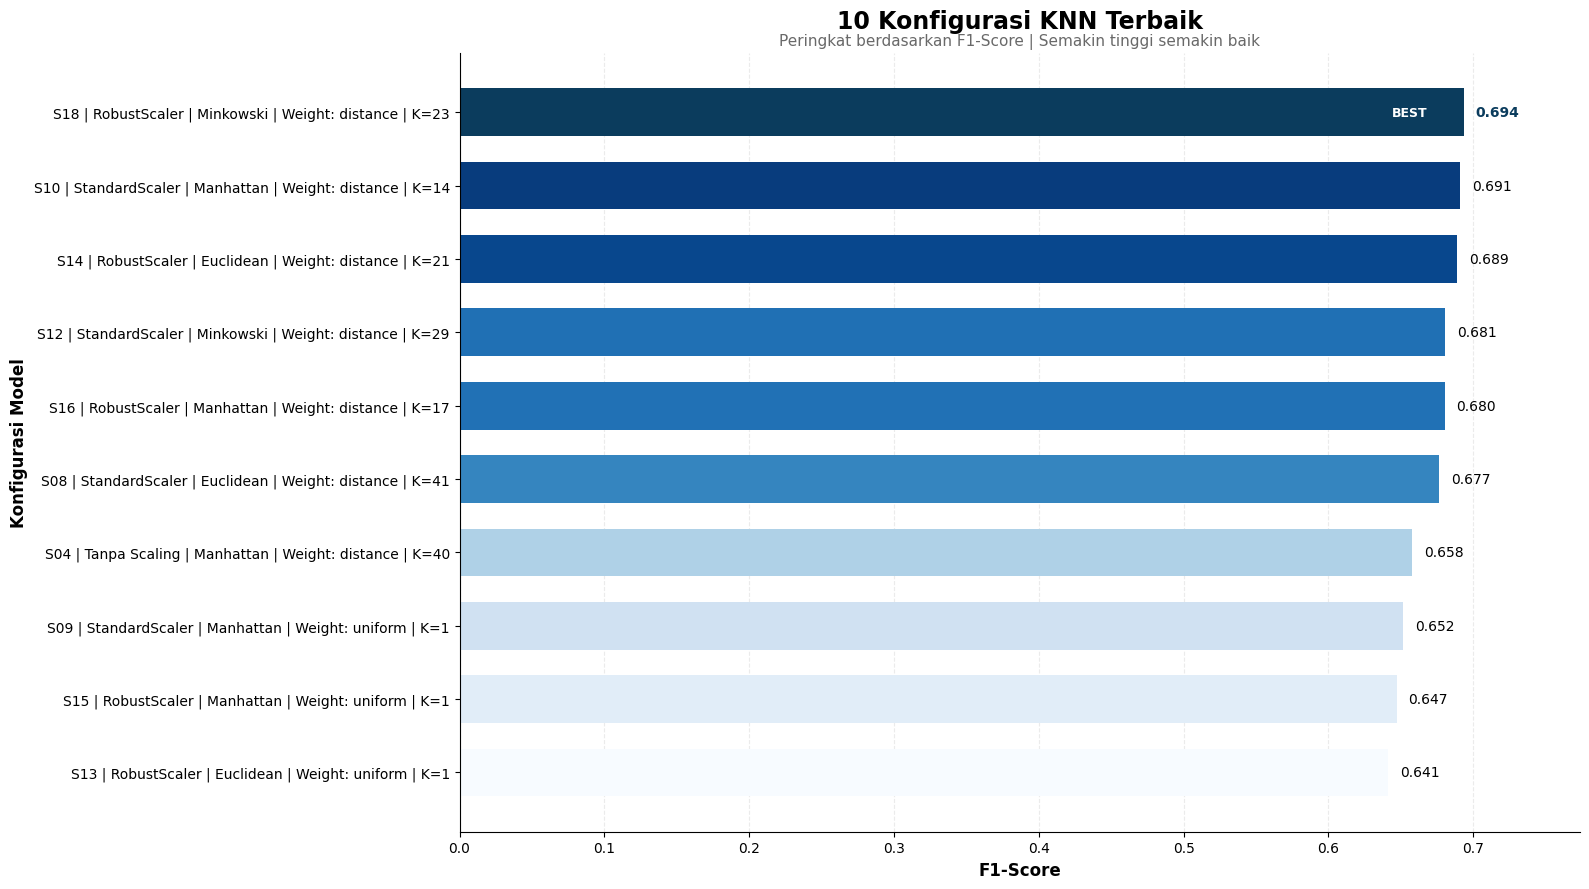

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ============================================================
# Persiapan data
# ============================================================

plot_data = top_10.copy()

# Urutkan dari F1-Score tertinggi ke terendah
plot_data = plot_data.sort_values(
    "F1-Score",
    ascending=False
).reset_index(drop=True)

# Label lengkap untuk setiap konfigurasi
plot_data["Label"] = (
    plot_data["Skenario"]
    + " | "
    + plot_data["Scaling"]
    + " | "
    + plot_data["Distance"]
    + " | Weight: "
    + plot_data["Weight"]
    + " | K="
    + plot_data["K"].astype(str)
)

# ============================================================
# Warna
# ============================================================

# Gradasi warna berdasarkan F1-Score
norm = plt.Normalize(
    plot_data["F1-Score"].min(),
    plot_data["F1-Score"].max()
)

cmap = plt.cm.Blues

colors = [
    cmap(norm(value))
    for value in plot_data["F1-Score"]
]

# Model terbaik diberi warna khusus
colors[0] = "#0B3C5D"

# ============================================================
# Plot
# ============================================================

fig, ax = plt.subplots(
    figsize=(16, 9)
)

y_pos = np.arange(len(plot_data))

bars = ax.barh(
    y_pos,
    plot_data["F1-Score"],
    color=colors,
    height=0.65
)

# Model terbaik berada di paling atas
ax.invert_yaxis()

# ============================================================
# Label konfigurasi
# ============================================================

ax.set_yticks(y_pos)

ax.set_yticklabels(
    plot_data["Label"],
    fontsize=10
)

# ============================================================
# Nilai F1-Score
# ============================================================

for i, (bar, value) in enumerate(
    zip(bars, plot_data["F1-Score"])
):

    # Label nilai
    ax.text(
        value + 0.008,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.3f}",
        va="center",
        fontsize=10,
        fontweight="bold" if i == 0 else "normal",
        color="#0B3C5D" if i == 0 else "black"
    )

    # Tanda BEST untuk model terbaik
    if i == 0:
        ax.text(
            value - 0.025,
            bar.get_y() + bar.get_height() / 2,
            "BEST",
            va="center",
            ha="right",
            fontsize=9,
            fontweight="bold",
            color="white"
        )

# ============================================================
# Judul
# ============================================================

ax.set_title(
    "10 Konfigurasi KNN Terbaik",
    fontsize=17,
    fontweight="bold",
    pad=18
)

ax.text(
    0.5,
    1.01,
    "Peringkat berdasarkan F1-Score | Semakin tinggi semakin baik",
    transform=ax.transAxes,
    ha="center",
    fontsize=11,
    color="dimgray"
)

# ============================================================
# Sumbu
# ============================================================

ax.set_xlabel(
    "F1-Score",
    fontsize=12,
    fontweight="bold"
)

ax.set_ylabel(
    "Konfigurasi Model",
    fontsize=12,
    fontweight="bold"
)

# Beri ruang agar label nilai tidak terpotong
ax.set_xlim(
    0,
    plot_data["F1-Score"].max() + 0.08
)

# ============================================================
# Grid
# ============================================================

ax.xaxis.grid(
    True,
    linestyle="--",
    alpha=0.25
)

ax.set_axisbelow(True)

# Hilangkan garis atas dan kanan
sns.despine(
    ax=ax,
    top=True,
    right=True
)

plt.tight_layout()

plt.show()



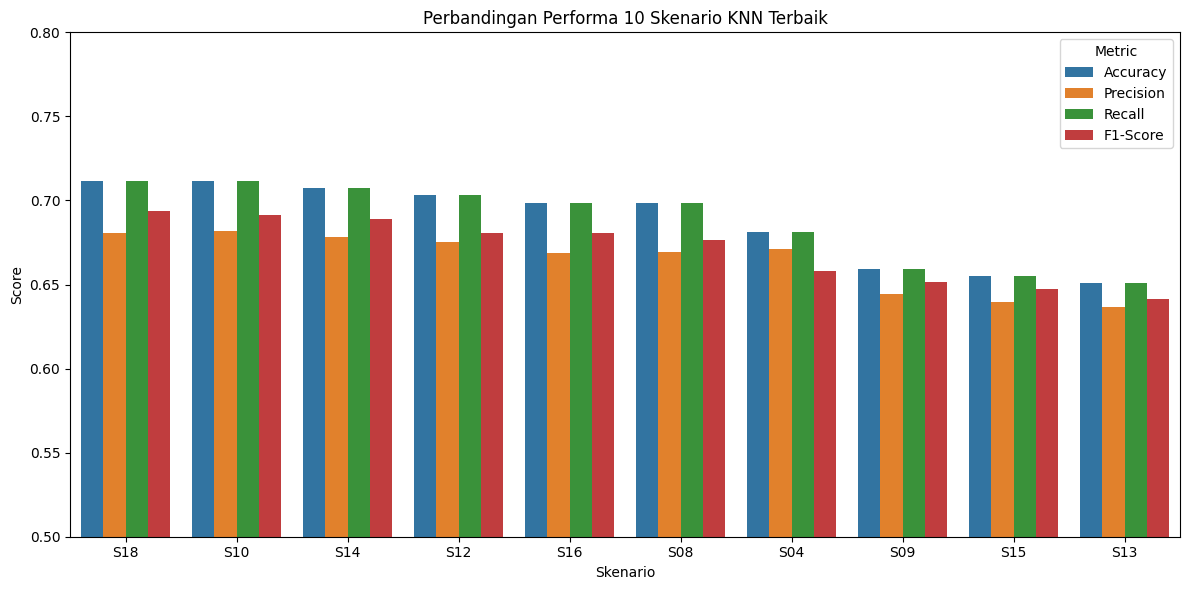

In [61]:
# Ubah data menjadi format yang cocok untuk grafik
metric_data = top_10.melt(
    id_vars=["Skenario"],
    value_vars=[
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score"
    ],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=metric_data,
    x="Skenario",
    y="Score",
    hue="Metric"
)

plt.title("Perbandingan Performa 10 Skenario KNN Terbaik")
plt.xlabel("Skenario")
plt.ylabel("Score")
plt.ylim(0.5, 0.8)

plt.legend(title="Metric")
plt.tight_layout()
plt.show()


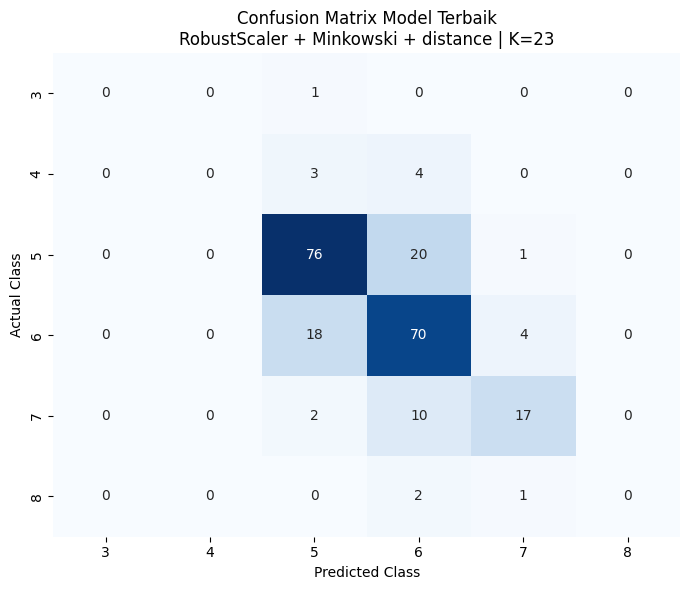

In [62]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Ambil model terbaik
best_model = top_10.iloc[0]

scaling = best_model["Scaling"]
distance = best_model["Distance"]
weight = best_model["Weight"]
k = int(best_model["K"])

# Ambil data sesuai scaling
Xtr, Xte = data_scaling[scaling]

# Parameter distance
distance_params = {
    "Euclidean": {"metric": "minkowski", "p": 2},
    "Manhattan": {"metric": "manhattan"},
    "Minkowski": {"metric": "minkowski", "p": 3}
}

# Buat model
knn = KNeighborsClassifier(
    n_neighbors=k,
    weights=weight,
    **distance_params[distance]
)

# Training
knn.fit(Xtr, Y_train)

# Prediksi
Y_pred = knn.predict(Xte)

# Confusion Matrix
labels = sorted(Y_test.unique())

cm = confusion_matrix(
    Y_test,
    Y_pred,
    labels=labels
)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels,
    cbar=False
)

plt.title(
    f"Confusion Matrix Model Terbaik\n"
    f"{scaling} + {distance} + {weight} | K={k}"
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.tight_layout()
plt.show()


# 5. Analisis

### Jelaskan secara detail hasil analisis yang didapatkan dari eksperimen model KNN yang telah dilakukan. Bandingkan hasil antar eksperimen yang telah dilakukan. Pastikan analisis didasari oleh hasil eksperimen sendiri yang telah dilakukan.  

## Analisis Hasil Eksperimen KNN

Eksperimen dilakukan untuk mengetahui kombinasi konfigurasi yang memberikan
performa terbaik pada algoritma **K-Nearest Neighbors (KNN)**. Pengujian
melibatkan tiga metode scaling, yaitu **Tanpa Scaling, StandardScaler, dan
RobustScaler**, tiga jenis distance, yaitu **Euclidean, Manhattan, dan
Minkowski**, serta dua metode pembobotan tetangga (**Weight**), yaitu
`uniform` dan `distance`.

Setiap kombinasi konfigurasi diuji menggunakan nilai $K$ dari $1$ hingga $100$.
Dari seluruh hasil eksperimen, konfigurasi kemudian dibandingkan berdasarkan
nilai **F1-Score** sebagai metrik utama. F1-Score digunakan karena distribusi
kelas pada dataset tidak seimbang, dengan kelas `quality = 5` dan `quality = 6`
memiliki jumlah data yang jauh lebih besar dibandingkan kelas lainnya.

### Hasil Terbaik

Berdasarkan seluruh hasil pengujian, konfigurasi dengan performa terbaik
adalah:

**RobustScaler + Minkowski + Weight `distance` + $K=23$**

dengan hasil:

- **Accuracy:** $0.7118$
- **Precision:** $0.6808$
- **Recall:** $0.7118$
- **F1-Score:** $0.6937$

Konfigurasi tersebut memiliki **F1-Score tertinggi** dari konfigurasi yang
diuji. Selain memiliki F1-Score paling tinggi, nilai Accuracy dan Recall juga
mencapai $0.7118$, sehingga konfigurasi ini memberikan performa yang relatif
seimbang antara ketepatan prediksi dan kemampuan model dalam mengenali kelas
yang benar.

### Pengaruh Scaling

Hasil eksperimen menunjukkan bahwa penggunaan scaling memberikan peningkatan
performa dibandingkan penggunaan data tanpa scaling.

Konfigurasi terbaik tanpa scaling adalah:

**Tanpa Scaling + Manhattan + Weight `distance` + $K=40$**

dengan:

$$
F1 = 0.6580
$$

Sementara konfigurasi terbaik secara keseluruhan menggunakan RobustScaler dan
mencapai:

$$
F1 = 0.6937
$$

Terdapat peningkatan sebesar:

$$
0.6937 - 0.6580 = 0.0357
$$

atau sekitar **3,57 poin F1-Score**.

Hal ini menunjukkan bahwa scaling memiliki peranan penting pada KNN. KNN
menentukan tetangga berdasarkan jarak antar-observasi, sehingga perbedaan
rentang antarfitur dapat memengaruhi hasil perhitungan jarak. Dengan scaling,
kontribusi antarfitur menjadi lebih terkendali sehingga proses pencarian
tetangga dapat bekerja dengan lebih baik.

### RobustScaler dan Hasil EDA

Pemilihan RobustScaler pada tahap preprocessing sebelumnya didasarkan pada
karakteristik dataset yang ditemukan melalui EDA. Beberapa fitur memiliki
skewness yang cukup tinggi, seperti `residual sugar` sebesar $4.36$,
`chlorides` sebesar $6.03$, dan `sulphates` sebesar $2.50$. Selain itu,
analisis menggunakan IQR menunjukkan adanya cukup banyak outlier, terutama
pada `residual sugar` sebanyak 110 data (9,62%) dan `chlorides` sebanyak 77
data (6,74%).

Berdasarkan karakteristik tersebut, **RobustScaler dipilih sebagai kandidat
scaling yang sesuai** karena menggunakan median dan IQR sehingga lebih tahan
terhadap pengaruh nilai ekstrem.

Menariknya, hasil eksperimen memberikan dukungan terhadap pertimbangan
tersebut. Konfigurasi dengan performa tertinggi menggunakan:

**RobustScaler + Minkowski + Weight `distance` + $K=23$**

dengan F1-Score sebesar **0.6937**.

Dengan demikian, pemilihan RobustScaler tidak hanya berdasarkan asumsi
teoritis dari hasil EDA, tetapi juga didukung oleh hasil eksperimen. Namun,
hasil ini tidak berarti bahwa RobustScaler selalu lebih baik daripada
StandardScaler. Performa tetap bergantung pada kombinasi scaling, distance,
weight, dan nilai $K$.

### Perbandingan StandardScaler dan RobustScaler

Baik **StandardScaler** maupun **RobustScaler** menghasilkan beberapa
konfigurasi dengan performa tinggi.

Beberapa konfigurasi terbaik menggunakan RobustScaler:

- RobustScaler + Minkowski + `distance`, $K=23$ → F1-Score **0.6937**
- RobustScaler + Euclidean + `distance`, $K=21$ → F1-Score **0.6890**
- RobustScaler + Manhattan + `distance`, $K=17$ → F1-Score **0.6804**

Sementara itu, StandardScaler juga menghasilkan performa yang tinggi:

- StandardScaler + Manhattan + `distance`, $K=14$ → F1-Score **0.6911**
- StandardScaler + Minkowski + `distance`, $K=29$ → F1-Score **0.6806**
- StandardScaler + Euclidean + `distance`, $K=41$ → F1-Score **0.6765**

Konfigurasi terbaik RobustScaler memiliki F1-Score **0.6937**, sedangkan
konfigurasi terbaik StandardScaler mencapai **0.6911**. Selisihnya hanya:

$$
0.6937 - 0.6911 = 0.0026
$$

Artinya, kedua scaler memberikan performa yang relatif berdekatan. Meskipun
demikian, pada eksperimen ini **RobustScaler menghasilkan konfigurasi terbaik
secara keseluruhan**.

Hasil tersebut juga konsisten dengan karakteristik dataset yang ditemukan
pada tahap EDA, yaitu adanya fitur dengan skewness tinggi dan cukup banyak
outlier.

### Pengaruh Distance Metric

Tiga distance yang diuji adalah **Euclidean, Manhattan, dan Minkowski**.

Konfigurasi terbaik dari masing-masing distance adalah:

| Distance | Scaling | Weight | $K$ | F1-Score |
|:---|:---|:---|---:|---:|
| Minkowski | RobustScaler | `distance` | 23 | **0.6937** |
| Manhattan | StandardScaler | `distance` | 14 | **0.6911** |
| Euclidean | RobustScaler | `distance` | 21 | **0.6890** |

Berdasarkan hasil tersebut, **Minkowski menghasilkan konfigurasi dengan
F1-Score tertinggi**. Namun, perbedaannya dengan Manhattan dan Euclidean
relatif kecil. Oleh karena itu, hasil eksperimen menunjukkan adanya
perbedaan performa antar-distance, tetapi tidak menunjukkan bahwa satu jenis
distance selalu unggul pada semua kondisi preprocessing.

Minkowski digunakan dengan $p=3$, sehingga berbeda dari Euclidean ($p=2$) dan
Manhattan ($p=1$):

$$
d(x,y)=
\left(
\sum_{i=1}^{n}|x_i-y_i|^p
\right)^{\frac{1}{p}}
$$

Dalam eksperimen ini, kombinasi $p=3$ dengan RobustScaler dan weight
`distance` menghasilkan performa terbaik.

### Pengaruh Weight

Eksperimen juga membandingkan dua metode pembobotan tetangga:

- `uniform`: seluruh tetangga memiliki bobot yang sama.
- `distance`: tetangga yang memiliki jarak lebih dekat diberikan pengaruh
  yang lebih besar.

Berdasarkan 10 konfigurasi dengan performa terbaik, metode `distance`
mendominasi hasil eksperimen. **7 dari 10 konfigurasi terbaik menggunakan
weight `distance`**, sedangkan 3 lainnya menggunakan `uniform`.

Konfigurasi terbaik dengan `distance` adalah:

**RobustScaler + Minkowski + $K=23$**

dengan:

$$
F1 = 0.6937
$$

Sementara konfigurasi terbaik dengan `uniform` adalah:

**StandardScaler + Manhattan + $K=1$**

dengan:

$$
F1 = 0.6517
$$

Perbedaan tersebut menunjukkan bahwa pada eksperimen ini, penggunaan
`distance` cenderung memberikan performa yang lebih baik dibandingkan
`uniform`. Secara intuitif, hal ini masuk akal karena data yang lebih dekat
dengan data yang akan diklasifikasikan diberikan pengaruh lebih besar dalam
menentukan kelas.



# 6. Kesimpulan dan Saran

### Kesimpulan

Berdasarkan seluruh eksperimen, konfigurasi KNN terbaik adalah:

$$
\boxed{
\text{RobustScaler}
+
\text{Minkowski}
+
\text{Weight = distance}
+
K=23
}
$$

dengan hasil:

- **Accuracy:** $0.7118$
- **Precision:** $0.6808$
- **Recall:** $0.7118$
- **F1-Score:** $0.6937$

F1-Score digunakan sebagai dasar pemilihan model karena distribusi kelas
`quality` tidak seimbang, terutama kelas `quality = 5` dan `quality = 6`
yang mendominasi dataset.

Hasil eksperimen juga menunjukkan bahwa **scaling membantu meningkatkan
performa KNN**. Konfigurasi terbaik tanpa scaling hanya menghasilkan
F1-Score $0.6580$, sedangkan konfigurasi terbaik dengan scaling mencapai
$0.6937$.

Pemilihan **RobustScaler** pada tahap preprocessing sebelumnya didasarkan
pada adanya skewness tinggi dan outlier pada beberapa fitur. Hasil eksperimen
kemudian mendukung pertimbangan tersebut karena konfigurasi terbaik
menggunakan RobustScaler.

Secara keseluruhan, performa KNN dipengaruhi oleh kombinasi **scaling,
distance, weight, dan nilai $K$**, bukan hanya satu parameter.

### Saran

Untuk pengembangan selanjutnya, model dapat diuji menggunakan:

1. **K-Fold Cross-Validation** untuk memastikan hasil tidak bergantung pada
   satu pembagian data.
2. **SMOTE atau oversampling** untuk menangani ketidakseimbangan kelas.
3. **Evaluasi per kelas** menggunakan Confusion Matrix dan Macro F1-Score.
4. Pengujian nilai $K$ di sekitar $23$ untuk mencari konfigurasi yang lebih
   optimal.

> **Kesimpulan akhir:** RobustScaler yang awalnya dipilih berdasarkan hasil
> EDA ternyata juga menghasilkan konfigurasi KNN terbaik setelah dilakukan
> eksperimen, yaitu **RobustScaler + Minkowski + Weight `distance` + $K=23$**
> dengan **F1-Score $0.6937$**.
